# Phase 3: Data Modeling & Evaluation
Áp dụng Machine Learning (Multiple Linear Regression) để tìm ra quy luật và dự báo nhu cầu thuê xe theo thời gian. Bước này sẽ thiết lập đường cơ sở (Baseline) và trực quan hóa phân tích sai số (Residual Plot).

In [3]:
%load_ext autoreload
%autoreload 2

import sys
import os
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..')) if current_dir.endswith('notebooks') else current_dir
if project_root not in sys.path:
    sys.path.append(project_root)

from src.forecaster import DemandForecaster
forecaster = DemandForecaster(clean_dir=os.path.join(project_root, 'dataclean'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Volumes/Vien/DS/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Xây dựng mô hình Dự báo cho Chicago (Divvy Bike)
Mô hình sẽ tiến hành gom nhóm (Group by hour) bằng DuckDB để tạo chuỗi thời gian, áp dụng One-Hot Encoding, chạy Train-Test Split (80/20) và đánh giá bằng 5-Fold Cross Validation.

=== BƯỚC 1: CHUẨN BỊ DỮ LIỆU (DIVVY) ===
Đang tính toán Design Matrix X và Target y qua DuckDB...
Tổng số khung giờ thu thập được: 9,478 dòng (đủ nhỏ để đưa vào RAM và Scikit-Learn).
Đang thực hiện One-Hot Encoding cho Hour_of_day và Day_of_week...

=== BƯỚC 2: PHÂN TÁCH DỮ LIỆU (TRAIN-TEST SPLIT) ===
Tập Training: 7,582 dòng (80%)
Tập Test: 1,896 dòng (20%)

=== BƯỚC 3 & 4: THIẾT LẬP MÔ HÌNH, HÀM MẤT MÁT & TỐI ƯU HÓA ===
1. Hàm mất mát (Loss Function):
   - MSE (Mean Squared Error): Phạt rất nặng các sai số lớn. Sẽ bị ảnh hưởng nếu có những ngày đột biến (lễ hội).
   - MAE (Mean Absolute Error): Độ lệch tuyệt đối trung bình, chống chịu tốt với Outliers. Cho biết trung bình mỗi giờ mô hình dự báo lệch bao nhiêu xe.

2. Thuật toán Tối ưu (Optimization):
   - Khởi chạy Linear Regression của Scikit-Learn giải bài toán cực tiểu hóa bằng phương pháp Ordinary Least Squares (OLS) tìm trọng số Theta tối ưu.

[MÔ HÌNH 1: THE CONSTANT MODEL (BASELINE)]
Dự đoán hằng số trung bình (Mean) cho mọi k

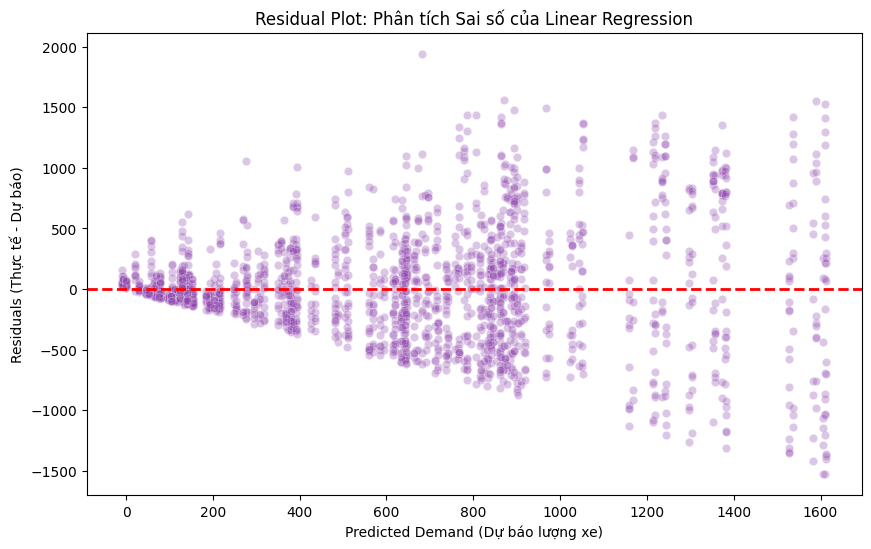

🔍 Nhận xét Residual Plot:
 Lý tưởng nhất là các điểm sai số phân tán ngẫu nhiên đều quanh vạch 0 (không quy luật).
 Nếu đồ thị có hình nón phễu tòe ra (Heteroskedasticity), chứng tỏ ở những giờ cao điểm mô hình dự báo sai số càng cao. Lúc này Linear Regression đã đến giới hạn, ta cần nâng cấp lên mô hình phi tuyến tính phức tạp hơn như Random Forest hay XGBoost trong tương lai.


In [4]:
city = 'divvy'

# 1. Chuẩn bị Design Matrix X và Target y
X_train, X_test, y_train, y_test = forecaster.prepare_data(city)

# 2. Huấn luyện, giải thích Loss Function & Đánh giá Inference
forecaster.train_and_evaluate()

*(Tương tự, để chạy cho Citi Bike (New York), bạn chỉ cần đổi `city = 'citibike'`)*

### Nâng cấp Mô hình: Random Forest & Optuna
Sử dụng Optuna để dò tìm siêu tham số tối ưu và chạy thuật toán phi tuyến tính Random Forest nhằm thu hẹp hiện tượng sai số hình phễu của Linear Regression.


=== NÂNG CẤP MÔ HÌNH: RANDOM FOREST + OPTUNA ===
Đang chạy Optuna để tối ưu hóa siêu tham số (Hyperparameters)...

[KẾT QUẢ OPTUNA]
Tham số tốt nhất tìm được:
 - n_estimators: 100
 - max_depth: 14
 - min_samples_split: 7

Đang huấn luyện mô hình Random Forest cuối cùng với tham số tốt nhất...

[ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST]
 - MAE: 335.26 xe/giờ
 - RMSE: 464.76 xe/giờ
 - R2 Score: 0.4702 (Mô hình phi tuyến tính giải thích được 47.0% biến thiên!)

[FEATURE IMPORTANCES]
Top 5 biến quan trọng nhất ảnh hưởng đến nhu cầu:
 - hour_of_day_17: 22.76%
 - hour_of_day_16: 14.27%
 - hour_of_day_18: 11.06%
 - hour_of_day_15: 6.53%
 - is_weekend: 6.26%

Đang vẽ lại biểu đồ Residual Plot cho Random Forest...


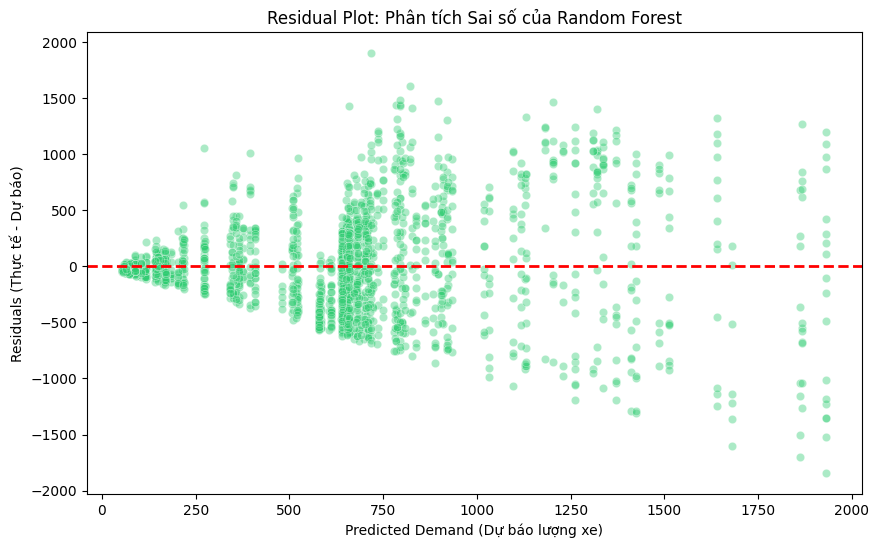

🔍 Nhận xét Residual Plot (Random Forest):
 Hình phễu đã được thu hẹp đáng kể so với Linear Regression. Tuy nhiên, nếu ở các mức lượng xe cực cao (>2000) sai số vẫn lớn,
 hệ thống bắt buộc phải thu thập thêm dữ liệu Thời tiết (Nhiệt độ, Mưa, Tuyết) để triệt tiêu hoàn toàn sai số này!


In [5]:
# Chạy dò tham số Optuna (đặt n_trials=5 để minh họa tính năng, tăng lên để tối ưu sâu hơn)
forecaster.train_complex_models(n_trials=5)